# Evaluación de la rentabilidad del modelo

## 1. ¿Qué se está evaluando?

Este notebook evalúa el resultado económico del **backtest de apuestas** generado por el modelo. La pregunta central no es solo cuánto dinero terminó ganando la estrategia, sino cuánto obtuvo por cada unidad apostada, qué riesgo asumió y si el resultado se mantiene al separar mercados y niveles de valor esperado.

- **ROI:** beneficio neto dividido entre el capital total apostado. Mide la eficiencia de la estrategia, no el crecimiento de la cuenta.
- **Balance:** capital inicial más el P/L acumulado. Se observa al cierre de cada fecha con actividad.
- **Drawdown:** caída del balance diario desde su máximo anterior. Resume el riesgo experimentado durante el periodo.
- **EV:** ventaja estimada por el modelo antes de conocer el resultado.

El análisis describe un backtest histórico. No demuestra que el mismo rendimiento vaya a repetirse fuera de muestra o en producción.

In [1]:
from pathlib import Path
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=UserWarning)

BLUE = "#2563EB"
BLUE_LIGHT = "#BFDBFE"
GOLD = "#D89B19"
GOLD_LIGHT = "#FDE7A9"
INK = "#1F2937"
MUTED = "#6B7280"
GRID = "#E5E7EB"
PAPER = "#FCFCFA"
GREY = "#9CA3AF"
GREY_LIGHT = "#EEF0F3"

plt.rcParams.update({
    "figure.facecolor": PAPER,
    "axes.facecolor": PAPER,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.size": 11.5,
    "axes.titleweight": "bold",
})


def clean_axes(ax, grid_axis="y", keep_left=True, keep_bottom=True):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(keep_left)
    ax.spines["bottom"].set_visible(keep_bottom)
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.8, alpha=0.8)
    ax.set_axisbelow(True)


def finish_chart(fig, subtitle, y=0.945):
    fig.text(0.06, y, subtitle, fontsize=10.3, color=MUTED, ha="left")
    fig.text(0.975, 0.985, "✦", fontsize=17, color=GOLD, ha="right", va="top")


data_candidates = [Path("02_data"), Path("../02_data")]
DATA_DIR = next((path for path in data_candidates if path.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("No se encontró la carpeta 02_data")

SOURCE_PATH = DATA_DIR / "betting_results.xlsx"
raw_bets = pd.read_excel(SOURCE_PATH)

required_columns = [
    "Match", "Date", "Market", "Market Group", "Odds", "Market Odds", "EV",
    "Result", "Bet Amount", "PL Amount", "Balance",
]
missing_columns = set(required_columns) - set(raw_bets.columns)
assert not missing_columns, f"Faltan columnas requeridas: {sorted(missing_columns)}"

bets = raw_bets.copy()
bets["Date"] = pd.to_datetime(bets["Date"], errors="raise")
numeric_columns = ["Odds", "Market Odds", "EV", "Result", "Bet Amount", "PL Amount", "Balance"]
for column in numeric_columns:
    bets[column] = pd.to_numeric(bets[column], errors="raise")

bets = bets.sort_values("Date", kind="stable").reset_index(drop=True)
assert not bets[required_columns].isna().any().any()
assert not bets.duplicated().any()
assert (bets["Bet Amount"] >= 0).all()
assert (bets["Market Odds"] > 0).all()

source_label = "02_data/betting_results.xlsx"
coverage = pd.DataFrame({
    "Indicador": ["Archivo fuente", "Apuestas", "Partidos", "Mercados", "Periodo", "Valores faltantes"],
    "Valor": [
        source_label,
        f"{len(bets):,}",
        f"{bets[['Date', 'Match']].drop_duplicates().shape[0]:,}",
        f"{bets['Market Group'].nunique():,}",
        f"{bets['Date'].min():%d/%m/%Y} – {bets['Date'].max():%d/%m/%Y}",
        f"{int(bets[required_columns].isna().sum().sum()):,}",
    ],
})

display(coverage.set_index("Indicador"))

,Valor
Indicador,
Archivo fuente,02_data/betting_results.xlsx
Apuestas,"5,101"
Partidos,481
Mercados,4
Periodo,03/01/2025 – 27/04/2025
Valores faltantes,0


## 2. Datos y preparación

La unidad de análisis es una apuesta. Varias apuestas pueden pertenecer al mismo partido, por lo que no deben tratarse como observaciones completamente independientes al cuantificar incertidumbre.

El archivo contiene liquidaciones completas y parciales: `Result` puede ser −1, −0.5, 0, 0.5 o 1. Los resultados con beneficio cero se consideran *pushes* y se mantienen en todos los totales. Una fila con importe apostado igual a cero también se conserva para reconciliar el archivo, aunque no aporta capital ni beneficio.

In [2]:
total_bets = len(bets)
total_wagered = bets["Bet Amount"].sum()
total_profit = bets["PL Amount"].sum()
roi = total_profit / total_wagered
win_rate = (bets["PL Amount"] > 0).mean()
push_rate = (bets["PL Amount"] == 0).mean()
final_balance = bets["Balance"].iloc[-1]
initial_bankroll = final_balance - total_profit
bankroll_return = final_balance / initial_bankroll - 1

daily = (
    bets.groupby("Date", as_index=False)
    .agg(Apuestas=("PL Amount", "size"), Apostado=("Bet Amount", "sum"), Beneficio=("PL Amount", "sum"))
)
daily["Balance"] = initial_bankroll + daily["Beneficio"].cumsum()
daily_peak = np.maximum.accumulate(np.r_[initial_bankroll, daily["Balance"].to_numpy()])[1:]
daily["Drawdown"] = daily["Balance"] / daily_peak - 1
max_drawdown = daily["Drawdown"].min()
max_drawdown_date = daily.loc[daily["Drawdown"].idxmin(), "Date"]

summary = pd.DataFrame({
    "Indicador": [
        "Apuestas", "Capital apostado", "Beneficio neto", "ROI",
        "Balance final", "Retorno del bankroll", "Tasa de acierto", "Drawdown máximo",
    ],
    "Resultado": [
        f"{total_bets:,}",
        f"${total_wagered:,.0f}",
        f"${total_profit:,.0f}",
        f"{roi:.2%}",
        f"${final_balance:,.0f}",
        f"{bankroll_return:.1%}",
        f"{win_rate:.1%}",
        f"{max_drawdown:.1%}",
    ],
})

display(summary.set_index("Indicador"))

,Resultado
Indicador,
Apuestas,"5,101"
Capital apostado,"$1,477,775"
Beneficio neto,"$129,420"
ROI,8.76%
Balance final,"$139,420"
Retorno del bankroll,1294.2%
Tasa de acierto,31.9%
Drawdown máximo,-67.3%


## 3. Rendimiento global

El ROI y el retorno del bankroll responden a preguntas distintas. El primero divide el beneficio entre todo el capital que rotó por las apuestas; el segundo compara el balance final contra el capital inicial y recoge la reinversión acumulada.

In [3]:
display(Markdown(
    f"""La estrategia apostó **&#36;{total_wagered:,.0f}** y obtuvo **&#36;{total_profit:,.0f}** de beneficio, equivalente a un **ROI de {roi:.2%}**. El balance pasó de **&#36;{initial_bankroll:,.0f}** a **&#36;{final_balance:,.0f}** porque el capital se reutilizó a lo largo de {total_bets:,} apuestas.

La tasa de acierto fue **{win_rate:.1%}**, con **{push_rate:.1%}** de liquidaciones sin beneficio ni pérdida. Una tasa de acierto aislada no determina rentabilidad: cuotas, tamaños de apuesta y pagos parciales también cambian el resultado."""
))

La estrategia apostó **&#36;1,477,775** y obtuvo **&#36;129,420** de beneficio, equivalente a un **ROI de 8.76%**. El balance pasó de **&#36;10,000** a **&#36;139,420** porque el capital se reutilizó a lo largo de 5,101 apuestas.

La tasa de acierto fue **31.9%**, con **4.9%** de liquidaciones sin beneficio ni pérdida. Una tasa de acierto aislada no determina rentabilidad: cuotas, tamaños de apuesta y pagos parciales también cambian el resultado.

## 4. Evolución del balance y riesgo

El panel superior muestra el balance al cierre de cada fecha con actividad. El inferior muestra cuánto capital se apostó ese día; separar ambas escalas evita confundir volumen con crecimiento.

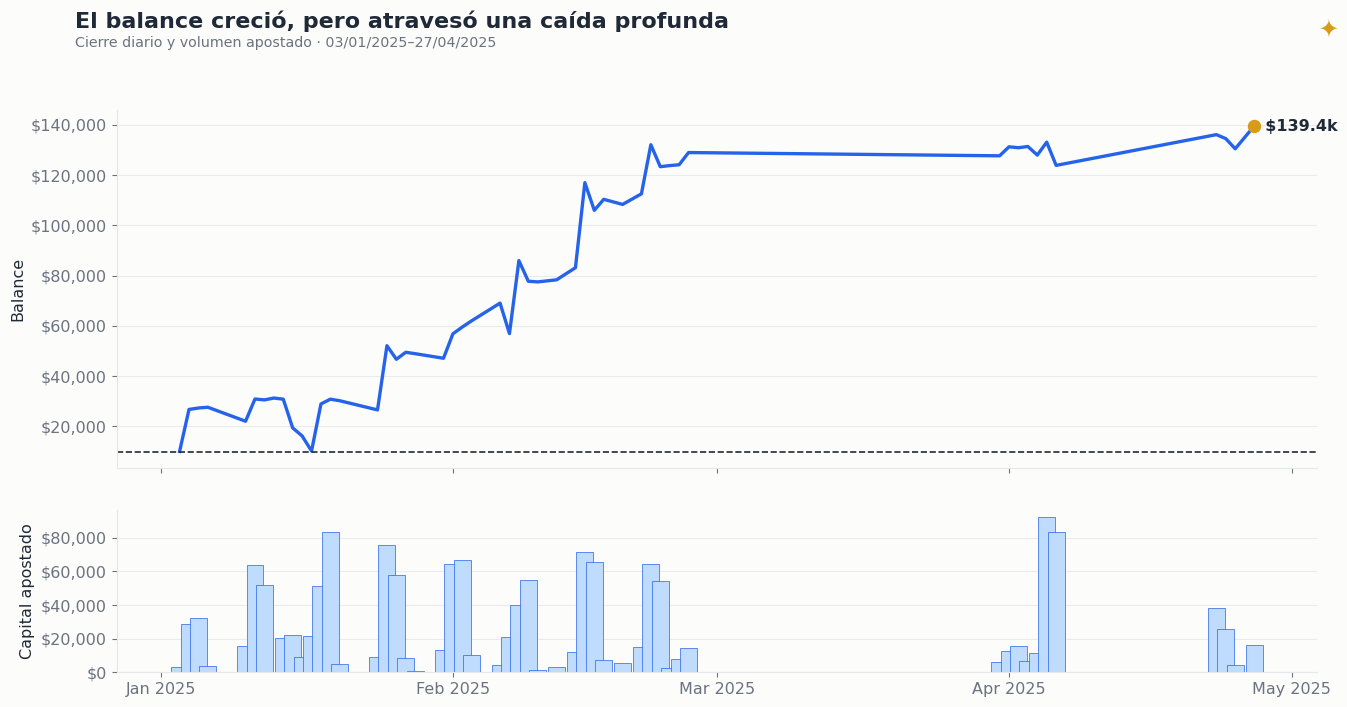

In [4]:
daily = (
    bets.groupby("Date", as_index=False)
    .agg(Apuestas=("PL Amount", "size"), Apostado=("Bet Amount", "sum"), Beneficio=("PL Amount", "sum"))
)
daily["Balance"] = initial_bankroll + daily["Beneficio"].cumsum()

fig, (ax_balance, ax_volume) = plt.subplots(
    2, 1, figsize=(13.8, 7.4), sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1], "hspace": 0.16},
)

ax_balance.plot(daily["Date"], daily["Balance"], color=BLUE, linewidth=2.4)
ax_balance.axhline(initial_bankroll, color=INK, linewidth=1.2, linestyle="--")
ax_balance.scatter(daily["Date"].iloc[-1], daily["Balance"].iloc[-1], color=GOLD, s=75, zorder=3)
ax_balance.text(
    daily["Date"].iloc[-1], daily["Balance"].iloc[-1],
    f"  ${final_balance/1000:.1f}k", va="center", color=INK, fontweight="bold",
)
ax_balance.set_ylabel("Balance")
ax_balance.yaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.0f}"))
clean_axes(ax_balance, grid_axis="y")

ax_volume.bar(daily["Date"], daily["Apostado"], width=1.8, color=BLUE_LIGHT, edgecolor=BLUE, linewidth=0.5)
ax_volume.set_ylabel("Capital apostado")
ax_volume.yaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.0f}"))
ax_volume.xaxis.set_major_locator(mdates.MonthLocator())
ax_volume.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
clean_axes(ax_volume, grid_axis="y")

fig.suptitle(
    "El balance creció, pero atravesó una caída profunda",
    x=0.06, y=0.995, ha="left", fontsize=16, fontweight="bold",
)
finish_chart(
    fig,
    f"Cierre diario y volumen apostado · {daily['Date'].min():%d/%m/%Y}–{daily['Date'].max():%d/%m/%Y}",
)
fig.subplots_adjust(left=0.09, right=0.96, bottom=0.10, top=0.86, hspace=0.18)
plt.show()

In [5]:
monthly = (
    bets.groupby(bets["Date"].dt.to_period("M"))
    .agg(Apuestas=("PL Amount", "size"), Apostado=("Bet Amount", "sum"), Beneficio=("PL Amount", "sum"))
)
monthly["ROI"] = monthly["Beneficio"] / monthly["Apostado"]
monthly.index = monthly.index.astype(str)

monthly_display = monthly.copy()
monthly_display["Apostado"] = monthly_display["Apostado"].map(lambda value: f"${value:,.0f}")
monthly_display["Beneficio"] = monthly_display["Beneficio"].map(lambda value: f"${value:,.0f}")
monthly_display["ROI"] = monthly_display["ROI"].map(lambda value: f"{value:.1%}")
monthly_display.index.name = "Mes"

display(monthly_display)
display(Markdown(
    f"""El drawdown máximo fue **{max_drawdown:.1%}** y ocurrió el **{max_drawdown_date:%d/%m/%Y}**. Además, marzo contiene solo **{int(monthly.loc['2025-03', 'Apuestas']):,} apuestas**; sus resultados no son comparables en volumen con enero, febrero o abril."""
))

,Apuestas,Apostado,Beneficio,ROI
Mes,,,,
2025-01,1975,"$577,612","$37,125",6.4%
2025-02,2201,"$587,478","$81,797",13.9%
2025-03,13,"$5,914","$-1,297",-21.9%
2025-04,912,"$306,771","$11,795",3.8%


El drawdown máximo fue **-67.3%** y ocurrió el **17/01/2025**. Además, marzo contiene solo **13 apuestas**; sus resultados no son comparables en volumen con enero, febrero o abril.

## 5. ¿Qué mercados explican el resultado?

Comparar únicamente el beneficio absoluto favorece a los mercados con mayor volumen. Por eso el gráfico utiliza ROI y la tabla conserva el capital apostado, el beneficio y el número de apuestas.

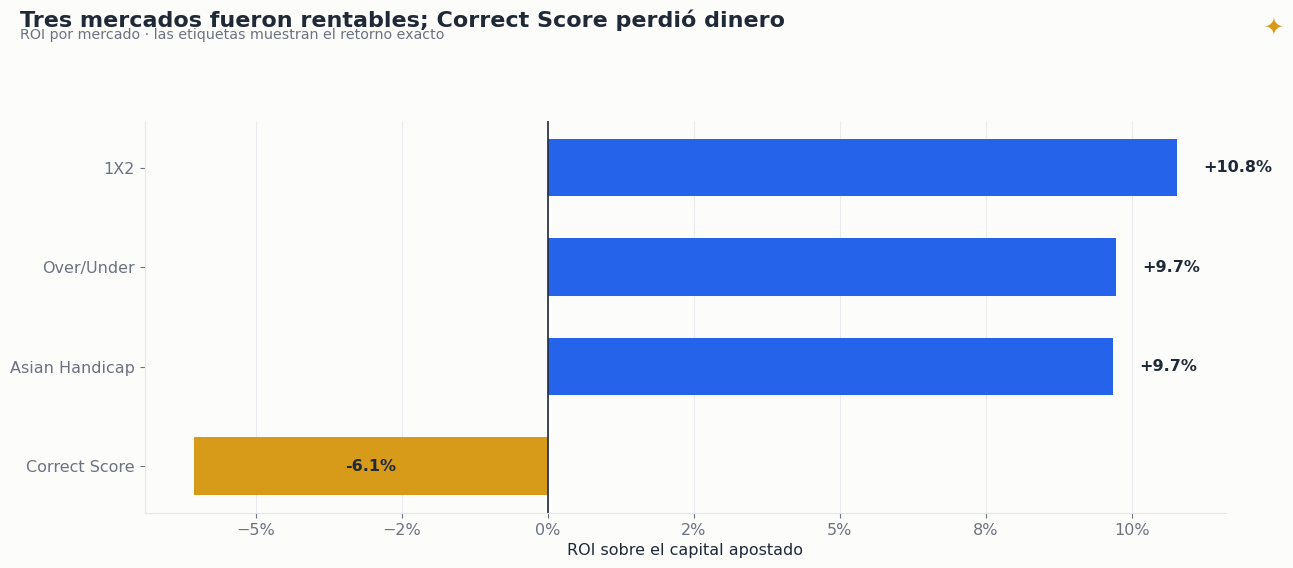

,Apuestas,Apostado,Beneficio,ROI,Acierto
Mercado,,,,,
Correct Score,1477,"$100,859","$-6,110",-6.1%,6.3%
Asian Handicap,1798,"$706,036","$68,291",9.7%,40.7%
Over/Under,1178,"$487,316","$47,453",9.7%,52.3%
1X2,648,"$183,564","$19,786",10.8%,28.4%


In [6]:
market_summary = (
    bets.groupby("Market Group")
    .agg(
        Apuestas=("PL Amount", "size"),
        Ganadas=("PL Amount", lambda values: (values > 0).sum()),
        Perdidas=("PL Amount", lambda values: (values < 0).sum()),
        Pushes=("PL Amount", lambda values: (values == 0).sum()),
        Apostado=("Bet Amount", "sum"),
        Beneficio=("PL Amount", "sum"),
    )
)
market_summary["ROI"] = market_summary["Beneficio"] / market_summary["Apostado"]
market_summary["Acierto"] = market_summary["Ganadas"] / market_summary["Apuestas"]
market_summary = market_summary.sort_values("ROI")

fig, ax = plt.subplots(figsize=(13.8, 5.8))
colors = [GOLD if value < 0 else BLUE for value in market_summary["ROI"]]
bars = ax.barh(market_summary.index, market_summary["ROI"] * 100, color=colors, height=0.58)
ax.axvline(0, color=INK, linewidth=1.2)

for bar, value in zip(bars, market_summary["ROI"] * 100):
    label_x = value + 0.45 if value >= 0 else value / 2
    ax.text(
        label_x, bar.get_y() + bar.get_height() / 2,
        f"{value:+.1f}%", va="center", ha="left" if value >= 0 else "center",
        fontweight="bold", color=INK,
    )

ax.set_xlabel("ROI sobre el capital apostado")
ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=100, decimals=0))
clean_axes(ax, grid_axis="x")
fig.suptitle(
    "Tres mercados fueron rentables; Correct Score perdió dinero",
    x=0.06, y=0.995, ha="left", fontsize=16, fontweight="bold",
)
finish_chart(fig, "ROI por mercado · las etiquetas muestran el retorno exacto")
fig.tight_layout(rect=[0.04, 0.02, 0.98, 0.90])
plt.show()

market_display = market_summary[["Apuestas", "Apostado", "Beneficio", "ROI", "Acierto"]].copy()
market_display["Apostado"] = market_display["Apostado"].map(lambda value: f"${value:,.0f}")
market_display["Beneficio"] = market_display["Beneficio"].map(lambda value: f"${value:,.0f}")
market_display["ROI"] = market_display["ROI"].map(lambda value: f"{value:.1%}")
market_display["Acierto"] = market_display["Acierto"].map(lambda value: f"{value:.1%}")
market_display.index.name = "Mercado"
display(market_display)

In [7]:
correct_score = market_summary.loc["Correct Score"]
profitable_markets = market_summary[market_summary["ROI"] > 0]
best_market = profitable_markets["ROI"].idxmax()

display(Markdown(
    f"""**Correct Score fue el único mercado no rentable:** perdió **&#36;{abs(correct_score['Beneficio']):,.0f}** y registró un ROI de **{correct_score['ROI']:.1%}** en {int(correct_score['Apuestas']):,} apuestas. El mejor ROI correspondió a **{best_market} ({market_summary.loc[best_market, 'ROI']:.1%})**.

La tasa de acierto no puede compararse directamente entre mercados con cuotas y estructuras de pago diferentes. El ROI ofrece una base común, aunque no mide por sí solo la volatilidad ni la calidad futura de cada segmento."""
))

**Correct Score fue el único mercado no rentable:** perdió **&#36;6,110** y registró un ROI de **-6.1%** en 1,477 apuestas. El mejor ROI correspondió a **1X2 (10.8%)**.

La tasa de acierto no puede compararse directamente entre mercados con cuotas y estructuras de pago diferentes. El ROI ofrece una base común, aunque no mide por sí solo la volatilidad ni la calidad futura de cada segmento.

## 6. ¿Un EV mayor produjo un retorno mayor?

Las apuestas se dividen en cinco grupos del mismo tamaño, ordenados por el EV previo al partido. El EV estimado se pondera por el importe apostado para compararlo con el ROI realizado sobre la misma base de capital.

Esta comparación evalúa ordenamiento, no calibración perfecta: un quintil con EV más alto debería tender a producir más retorno, pero el resultado realizado contiene mucha variación.

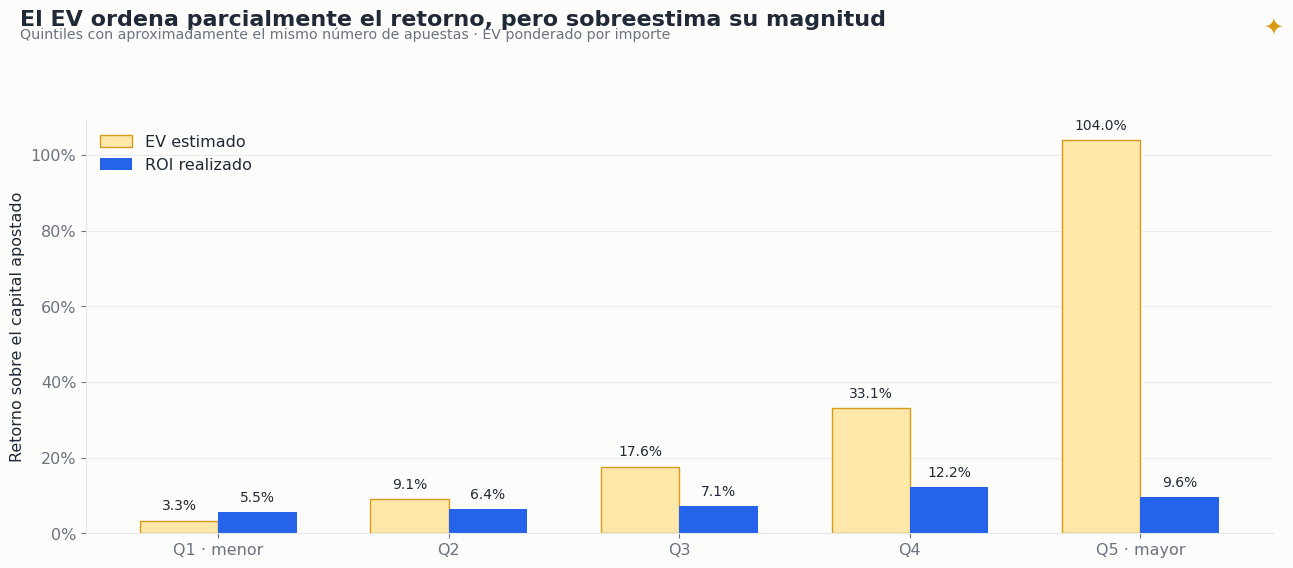

,Apuestas,Rango EV,Apostado,Beneficio,ROI realizado
Quintil EV,,,,,
Q1 · menor,1021,0.0%–5.4%,"$129,355","$7,121",5.5%
Q2,1020,5.4%–12.6%,"$264,125","$16,774",6.4%
Q3,1020,12.6%–23.5%,"$310,899","$22,039",7.1%
Q4,1020,23.5%–45.6%,"$355,927","$43,441",12.2%
Q5 · mayor,1020,45.6%–699.2%,"$417,469","$40,044",9.6%


In [8]:
ev_labels = ["Q1 · menor", "Q2", "Q3", "Q4", "Q5 · mayor"]
bets["Quintil EV"] = pd.qcut(bets["EV"], q=5, labels=ev_labels, duplicates="drop")
bets["Beneficio esperado"] = bets["EV"] * bets["Bet Amount"]

ev_summary = (
    bets.groupby("Quintil EV", observed=True)
    .agg(
        Apuestas=("PL Amount", "size"),
        EV_min=("EV", "min"),
        EV_max=("EV", "max"),
        Apostado=("Bet Amount", "sum"),
        Beneficio=("PL Amount", "sum"),
        Beneficio_esperado=("Beneficio esperado", "sum"),
    )
)
ev_summary["EV ponderado"] = ev_summary["Beneficio_esperado"] / ev_summary["Apostado"]
ev_summary["ROI realizado"] = ev_summary["Beneficio"] / ev_summary["Apostado"]

x = np.arange(len(ev_summary))
width = 0.34
fig, ax = plt.subplots(figsize=(13.8, 5.8))
expected_bars = ax.bar(
    x - width / 2, ev_summary["EV ponderado"] * 100, width,
    color=GOLD_LIGHT, edgecolor=GOLD, label="EV estimado",
)
realized_bars = ax.bar(
    x + width / 2, ev_summary["ROI realizado"] * 100, width,
    color=BLUE, label="ROI realizado",
)

for bars in (expected_bars, realized_bars):
    for bar in bars:
        value = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, value + 2,
            f"{value:.1f}%", ha="center", va="bottom", fontsize=10, color=INK,
        )

ax.set_ylabel("Retorno sobre el capital apostado")
ax.set_xticks(x, ev_summary.index)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=100, decimals=0))
ax.legend(frameon=False, loc="upper left")
clean_axes(ax, grid_axis="y")
fig.suptitle(
    "El EV ordena parcialmente el retorno, pero sobreestima su magnitud",
    x=0.06, y=0.995, ha="left", fontsize=16, fontweight="bold",
)
finish_chart(fig, "Quintiles con aproximadamente el mismo número de apuestas · EV ponderado por importe")
fig.tight_layout(rect=[0.04, 0.02, 0.98, 0.90])
plt.show()

ev_display = ev_summary[["Apuestas", "EV_min", "EV_max", "Apostado", "Beneficio", "ROI realizado"]].copy()
ev_display["Rango EV"] = [
    f"{low:.1%}–{high:.1%}" for low, high in zip(ev_display.pop("EV_min"), ev_display.pop("EV_max"))
]
ev_display["Apostado"] = ev_display["Apostado"].map(lambda value: f"${value:,.0f}")
ev_display["Beneficio"] = ev_display["Beneficio"].map(lambda value: f"${value:,.0f}")
ev_display["ROI realizado"] = ev_display["ROI realizado"].map(lambda value: f"{value:.1%}")
display(ev_display[["Apuestas", "Rango EV", "Apostado", "Beneficio", "ROI realizado"]])

In [9]:
lowest_roi = ev_summary["ROI realizado"].iloc[0]
fourth_roi = ev_summary["ROI realizado"].iloc[3]
highest_roi = ev_summary["ROI realizado"].iloc[4]
highest_expected_ev = ev_summary["EV ponderado"].iloc[4]

display(Markdown(
    f"""El ROI sube de **{lowest_roi:.1%}** en el quintil de menor EV a **{fourth_roi:.1%}** en el cuarto quintil, pero baja a **{highest_roi:.1%}** en el grupo de mayor EV. En ese último grupo, el EV ponderado era **{highest_expected_ev:.1%}**, muy por encima del retorno observado.

Por tanto, el EV contiene señal de ordenamiento, pero su magnitud no está calibrada como pronóstico directo del retorno realizado en esta muestra."""
))

El ROI sube de **5.5%** en el quintil de menor EV a **12.2%** en el cuarto quintil, pero baja a **9.6%** en el grupo de mayor EV. En ese último grupo, el EV ponderado era **104.0%**, muy por encima del retorno observado.

Por tanto, el EV contiene señal de ordenamiento, pero su magnitud no está calibrada como pronóstico directo del retorno realizado en esta muestra.

## 7. ¿Qué tan estable es el ROI observado?

Para respetar que varias apuestas pertenecen al mismo partido, el bootstrap remuestrea **partidos completos** identificados por fecha y encuentro. En cada réplica vuelve a calcular el ROI como beneficio total dividido entre capital total apostado.

El intervalo mide sensibilidad a la composición de esta muestra histórica. No corrige sobreajuste, sesgo de selección, dependencia entre partidos ni cambios futuros del mercado.

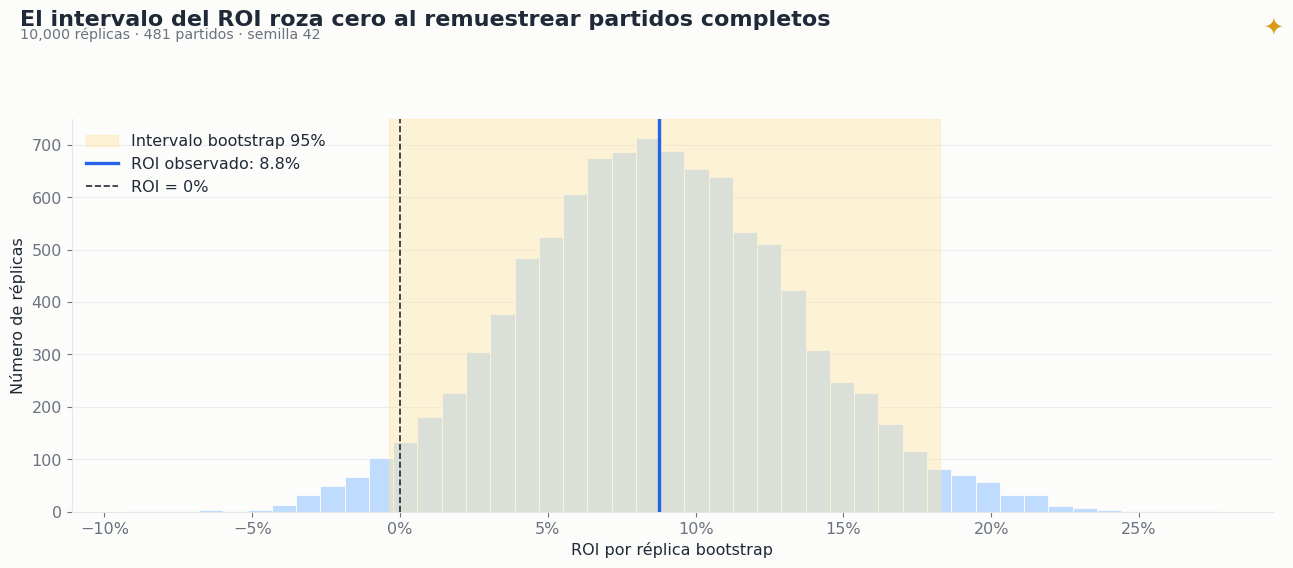

In [10]:
BOOTSTRAP_SEED = 42
N_BOOTSTRAP = 10_000

match_clusters = (
    bets.groupby(["Date", "Match"], as_index=False)
    .agg(Apostado=("Bet Amount", "sum"), Beneficio=("PL Amount", "sum"))
)
cluster_stakes = match_clusters["Apostado"].to_numpy()
cluster_profits = match_clusters["Beneficio"].to_numpy()

rng = np.random.default_rng(BOOTSTRAP_SEED)
sample_indices = rng.integers(
    0, len(match_clusters), size=(N_BOOTSTRAP, len(match_clusters))
)
bootstrap_stakes = cluster_stakes[sample_indices].sum(axis=1)
bootstrap_profits = cluster_profits[sample_indices].sum(axis=1)
bootstrap_roi = bootstrap_profits / bootstrap_stakes

ci_low, ci_high = np.quantile(bootstrap_roi, [0.025, 0.975])
share_nonpositive = (bootstrap_roi <= 0).mean()

fig, ax = plt.subplots(figsize=(13.8, 5.8))
ax.hist(bootstrap_roi * 100, bins=45, color=BLUE_LIGHT, edgecolor=PAPER, linewidth=0.6)
ax.axvspan(ci_low * 100, ci_high * 100, color=GOLD_LIGHT, alpha=0.45, label="Intervalo bootstrap 95%")
ax.axvline(roi * 100, color=BLUE, linewidth=2.4, label=f"ROI observado: {roi:.1%}")
ax.axvline(0, color=INK, linewidth=1.2, linestyle="--", label="ROI = 0%")
ax.set_xlabel("ROI por réplica bootstrap")
ax.set_ylabel("Número de réplicas")
ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=100, decimals=0))
ax.legend(frameon=False, loc="upper left")
clean_axes(ax, grid_axis="y")
fig.suptitle(
    "El intervalo del ROI roza cero al remuestrear partidos completos",
    x=0.06, y=0.995, ha="left", fontsize=16, fontweight="bold",
)
finish_chart(fig, f"{N_BOOTSTRAP:,} réplicas · {len(match_clusters):,} partidos · semilla {BOOTSTRAP_SEED}")
fig.tight_layout(rect=[0.04, 0.02, 0.98, 0.90])
plt.show()

In [11]:
display(Markdown(
    f"""El intervalo bootstrap del 95% va de **{ci_low:.1%} a {ci_high:.1%}**. En **{share_nonpositive:.1%}** de las réplicas el ROI fue igual o inferior a cero.

El resultado histórico es favorable, pero el límite inferior cercano a cero muestra que la rentabilidad depende de qué partidos forman la muestra. Este intervalo no debe interpretarse como una garantía de rendimiento futuro."""
))

El intervalo bootstrap del 95% va de **-0.4% a 18.3%**. En **3.1%** de las réplicas el ROI fue igual o inferior a cero.

El resultado histórico es favorable, pero el límite inferior cercano a cero muestra que la rentabilidad depende de qué partidos forman la muestra. Este intervalo no debe interpretarse como una garantía de rendimiento futuro.

In [12]:
display(Markdown(
    f"""## 8. Qué nos llevamos

- El backtest produjo **&#36;{total_profit:,.0f} de beneficio** sobre **&#36;{total_wagered:,.0f} apostados**, para un **ROI de {roi:.2%}**.
- La trayectoria no fue uniforme: el **drawdown máximo alcanzó {max_drawdown:.1%}**. El crecimiento final del balance no elimina ese riesgo intermedio.
- **Correct Score restó &#36;{abs(correct_score['Beneficio']):,.0f}** y fue el único grupo con ROI negativo; los otros tres mercados terminaron en positivo.
- Un EV mayor se relacionó con mejores retornos hasta el cuarto quintil, pero el grupo de mayor EV no mantuvo esa progresión y el modelo sobreestimó la magnitud esperada.
- El bootstrap agrupado por partido sitúa el ROI entre **{ci_low:.1%} y {ci_high:.1%}** en el 95% central de las réplicas. La evidencia es prometedora, pero todavía sensible a la composición del backtest.

En conjunto, el modelo mostró una ventaja económica histórica, acompañada por drawdowns elevados y señales de que el EV necesita calibración adicional antes de extrapolar el resultado."""
))

## 8. Qué nos llevamos

- El backtest produjo **&#36;129,420 de beneficio** sobre **&#36;1,477,775 apostados**, para un **ROI de 8.76%**.
- La trayectoria no fue uniforme: el **drawdown máximo alcanzó -67.3%**. El crecimiento final del balance no elimina ese riesgo intermedio.
- **Correct Score restó &#36;6,110** y fue el único grupo con ROI negativo; los otros tres mercados terminaron en positivo.
- Un EV mayor se relacionó con mejores retornos hasta el cuarto quintil, pero el grupo de mayor EV no mantuvo esa progresión y el modelo sobreestimó la magnitud esperada.
- El bootstrap agrupado por partido sitúa el ROI entre **-0.4% y 18.3%** en el 95% central de las réplicas. La evidencia es prometedora, pero todavía sensible a la composición del backtest.

En conjunto, el modelo mostró una ventaja económica histórica, acompañada por drawdowns elevados y señales de que el EV necesita calibración adicional antes de extrapolar el resultado.

## Checks de reproducibilidad

- Fuente congelada: `02_data/betting_results.xlsx`, hoja por defecto.
- Periodo: 03/01/2025–27/04/2025.
- ROI: beneficio neto total dividido entre capital total apostado.
- Balance inicial: balance final menos el beneficio neto total.
- Drawdown: caída del balance al cierre de cada fecha respecto de su máximo acumulado, incluyendo el capital inicial.
- Mercados y quintiles: cada total se reconcilia contra el portafolio completo.
- Quintiles de EV: cinco grupos de tamaño similar; EV agregado ponderado por importe apostado.
- Bootstrap: 10,000 réplicas con semilla 42, remuestreando por fecha y partido.
- Las conclusiones se generan desde los valores calculados durante la ejecución.

In [13]:
assert np.isclose(initial_bankroll + total_profit, final_balance, atol=1e-6)
assert market_summary["Apuestas"].sum() == total_bets
assert np.isclose(market_summary["Apostado"].sum(), total_wagered)
assert np.isclose(market_summary["Beneficio"].sum(), total_profit)
assert ev_summary["Apuestas"].sum() == total_bets
assert np.isclose(ev_summary["Apostado"].sum(), total_wagered)
assert np.isclose(ev_summary["Beneficio"].sum(), total_profit)
assert len(match_clusters) == bets[["Date", "Match"]].drop_duplicates().shape[0]

rng_check = np.random.default_rng(BOOTSTRAP_SEED)
check_indices = rng_check.integers(
    0, len(match_clusters), size=(N_BOOTSTRAP, len(match_clusters))
)
check_roi = (
    cluster_profits[check_indices].sum(axis=1)
    / cluster_stakes[check_indices].sum(axis=1)
)
assert np.array_equal(bootstrap_roi, check_roi)
assert ci_low <= roi <= ci_high

print("✓ Datos, métricas, reconciliaciones y bootstrap verificados.")

✓ Datos, métricas, reconciliaciones y bootstrap verificados.
